## **Name:** Rohan Khadye

## **Roll no:** 23102C0065

## **CMPN C**

## 1. Data Frames – Loading and inspecting `painters`

The lecture uses the `painters` data frame from the `MASS` package.  
The first commands load the package and display the data frame.

In [ ]:
library(MASS)
painters

,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


### Summary of a categorical variable

`summary()` gives a frequency summary for the categorical `School` variable.

In [ ]:
summary(painters$School)

A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

### Attaching a data frame

`attach()` allows variables in the data frame to be referenced directly by name, without repeatedly using `painters$`.

In [ ]:
attach(painters)
summary(School)  # Character/factor variable
summary(Composition)  # Numeric variable

A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.25   12.50   11.56   15.00   18.00 

### Selecting rows with `subset()`

The following commands select painters belonging to School F and painters whose composition score is at most 6.

In [ ]:
subset(painters, School == "F")
subset(painters, Composition <= 6)

,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Fr. Penni,0,15,8,0,A
Perugino,4,12,10,4,A
Bassano,6,8,17,0,D
Bellini,4,6,14,0,D
Murillo,6,8,15,4,D
Palma Vecchio,5,6,16,0,D
Caravaggio,6,6,16,0,E
Pourbus,4,15,6,6,F


### Selecting rows with bracket notation

The same School F subset can be obtained using row filtering with `[` and `[[ ]]`.

In [ ]:
painters[painters[["School"]] == "F", ]

,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


### Selecting columns with `subset()`

Uninteresting columns can be removed using the `select` argument. The lecture removes the third and fifth columns.

In [ ]:
subset(painters, School == "F", select = c(-3, -5))

,Composition,Drawing,Expression
,<int>,<int>,<int>
Durer,8,10,8
Holbein,9,10,13
Pourbus,4,15,6
Van Leyden,8,6,4


### Splitting a data frame

`split()` partitions the data frame according to the values of a variable. Here the data are divided according to `School`.

In [ ]:
splitted = split(painters, painters$School)
splitted

,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


### Checking one of the split objects

Each object such as `splitted$A` is itself a data frame.

In [ ]:
is.data.frame(splitted$A)

[1] TRUE

## 2. Importing and reading Excel and other data files

The lecture first shows how to set a working directory and use the `readxl` package for Excel files.

In [ ]:
# Example path from the lecture:
# setwd("C:/RCourse/")

# Install once if needed:
# install.packages("readxl")
library(readxl)

### Reading Excel files

`read_excel()` can read `.xlsx` and `.xls` files. A sheet can be selected by position or by name.

In [ ]:
# Examples from the lecture:
# read_excel("datafile.xlsx")
# read_excel("datafile.xls")
# read_excel(datasets, sheet_number)
# read_excel(datasets, "sheet_name")

### Reading an Excel sheet and extracting variables

The lecture reads the first sheet into `dataspexcel`, displays it, and then extracts columns using `$`.

In [ ]:
# Requires a file named "spexcel.xlsx" in the working directory.
# dataspexcel = read_excel("spexcel.xlsx", sheet = 1)
# dataspexcel
# dataspexcel$`Variable 1`
# dataspexcel$`Variable 2`
# mean(dataspexcel$`Variable 1`)

### Self-contained Excel example

To keep this notebook executable without an external Excel file, the same type of three-column data is created in R. This reproduces the calculations demonstrated in the lecture.

In [ ]:
dataspexcel <- data.frame(
  `Variable 1` = c(1, 2, 3, 4, 5),
  `Variable 2` = c(10, 20, 30, 40, 50),
  `Variable 3` = c(100, 200, 300, 400, 500),
  check.names = FALSE
)

dataspexcel
dataspexcel$`Variable 1`
dataspexcel$`Variable 2`
mean(dataspexcel$`Variable 1`)

Variable 1,Variable 2,Variable 3
<dbl>,<dbl>,<dbl>
1,10,100
2,20,200
3,30,300
4,40,400
5,50,500


[1] 1 2 3 4 5

[1] 10 20 30 40 50

[1] 3

### Reading a second Excel sheet

The lecture reads the second sheet into `dataspexcel2` and extracts its three variables.

In [ ]:
# External-file commands shown in the lecture:
# dataspexcel2 = read_excel("spexcel.xlsx", sheet = 2)
# dataspexcel2
# dataspexcel2$`Variable 4`
# dataspexcel2$`Variable 5`
# dataspexcel2$`Variable 6`
# mean(dataspexcel2$`Variable 6`)

### Self-contained second-sheet example

The following creates equivalent sample data so the extraction and mean calculation can be executed directly.

In [ ]:
dataspexcel2 <- data.frame(
  `Variable 4` = c(6, 7, 8, 9, 10),
  `Variable 5` = c(110, 120, 130, 140, 150),
  `Variable 6` = c(110, 210, 310, 410, 510),
  check.names = FALSE
)

dataspexcel2
dataspexcel2$`Variable 4`
dataspexcel2$`Variable 5`
dataspexcel2$`Variable 6`
mean(dataspexcel2$`Variable 6`)

Variable 4,Variable 5,Variable 6
<dbl>,<dbl>,<dbl>
6,110,110
7,120,210
8,130,310
9,140,410
10,150,510


[1]  6  7  8  9 10

[1] 110 120 130 140 150

[1] 110 210 310 410 510

[1] 310

### Limiting rows and selecting an Excel range

`n_max` limits the number of rows read. The `range` argument can read a specific A1 or R1C1 range.

In [ ]:
# Examples from the lecture:
# read_excel(datasets, n_max = 3)
# read_excel(datasets, range = "C1:E7")
# read_excel(datasets, range = "R1C2:R2C5")

# Executable demonstration using the sample data:
dataspexcel4 <- head(dataspexcel, 3)
dataspexcel4

,Variable 1,Variable 2,Variable 3
,<dbl>,<dbl>,<dbl>
1,1,10,100
2,2,20,200
3,3,30,300


### Reading SPSS data

The lecture uses the `foreign` package and `read.spss()` for SPSS `.sav` files.

In [ ]:
# Install once if needed:
# install.packages("foreign")
library(foreign)

# Example from the lecture:
# data = read.spss("datafile.sav")

### Reading HTML tables

The lecture uses the `XML` package and `readHTMLTable()` for HTML table data.

In [ ]:
# Install once if needed:
# install.packages("XML")
# library(XML)
# data = readHTMLTable("filename")

### Other formats supported by `foreign`

The lecture lists functions for Octave/MATLAB, SYSTAT, SAS XPORT and Stata files.

In [ ]:
# Examples from the lecture:
# read.octave("<Path to file>")
# read.systat("<Path to file>")
# read.xport("<Path to file>")
# read.dta("<Path to file>")

## 3. Saving and writing data files

The `write()` function can write data, usually a vector or matrix, to a file. The lecture also describes options such as the number of columns, appending and separators.

In [ ]:
# General form from the lecture:
# write(x, file = "data", ncolumns, append = FALSE, sep = " ")

### Writing a vector to a file

The lecture creates the numbers 1 to 100 and writes them to a file named `shalabh`. The following uses a temporary file so the notebook remains self-contained.

In [ ]:
x = c(1:100)
x

write(x, file = tempfile("shalabh_"))

[1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100

### Writing CSV and tabular data

`write.csv()` writes tabular data in CSV format, while `write.table()` writes a general table. The lecture also lists their important arguments.

In [ ]:
# General forms from the lecture:
# write.csv(x, file = "", append = FALSE)
# write.csv(x, file = "", append = FALSE, quote = TRUE, sep = " ",
#           eol = "\n", na = "NA", dec = ".", row.names = TRUE,
#           col.names = TRUE, qmethod = c("escape", "double"),
#           fileEncoding = "")

# write.table(x, file = "", append = FALSE)
# write.table(x, file = "", append = FALSE, quote = TRUE, sep = " ",
#             eol = "\n", na = "NA", dec = ".", row.names = TRUE,
#             col.names = TRUE, qmethod = c("escape", "double"),
#             fileEncoding = "")

## 4. Frequencies and partition values

`table()` creates absolute frequencies. Dividing the table by the vector length gives relative frequencies.

In [ ]:
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
gender

table(gender)  # Absolute frequencies
table(gender) / length(gender)  # Relative frequencies

[1] 1 2 1 2 1 1 1 2 1 1

gender
1 2 
7 3 

gender
  1   2 
0.7 0.3 

### Pizza home-delivery directions

The lecture codes East as 1, West as 2 and Central as 3 and calculates absolute and relative frequencies for 100 observations.

In [ ]:
direction = c(
  1,1,2,1,2,3,2,2,3,3,3,1,2,3,2,2,3,1,1,3,3,1,2,
  1,3,3,3,2,2,2,2,1,2,2,1,1,1,3,2,2,1,2,3,2,2,1,
  2,3,3,2,1,2,2,3,1,1,2,1,2,3,2,3,2,2,3,1,2,3,3,3,
  2,1,1,1,2,1,1,2,1,2,3,3,1,2,3,3,2,1,2,3,2,1,3,
  2,2,2,2,3,2,2
)

table(direction)
table(direction) / length(direction)

direction
 1  2  3 
28 43 29 

direction
   1    2    3 
0.28 0.43 0.29 

### Quantiles

Partition values divide data into parts. `quantile()` computes sample quantiles for probabilities between 0 and 1.

In [ ]:
marks = c(68, 82, 63, 86, 34, 96, 41, 89, 29, 51, 75, 77, 56, 59, 42)

quantile(marks)
quantile(marks, probs = c(0, 0.25, 0.5, 0.75, 1))
quantile(marks, probs = c(0, 0.20, 0.4, 0.6, 0.8, 1))

0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  20%  40%  60%  80% 100% 
29.0 41.8 57.8 70.8 82.8 96.0

## 5. Scatter plots

The lecture introduces `plot(x)` for a one-variable plot and demonstrates it using heights of 50 persons.

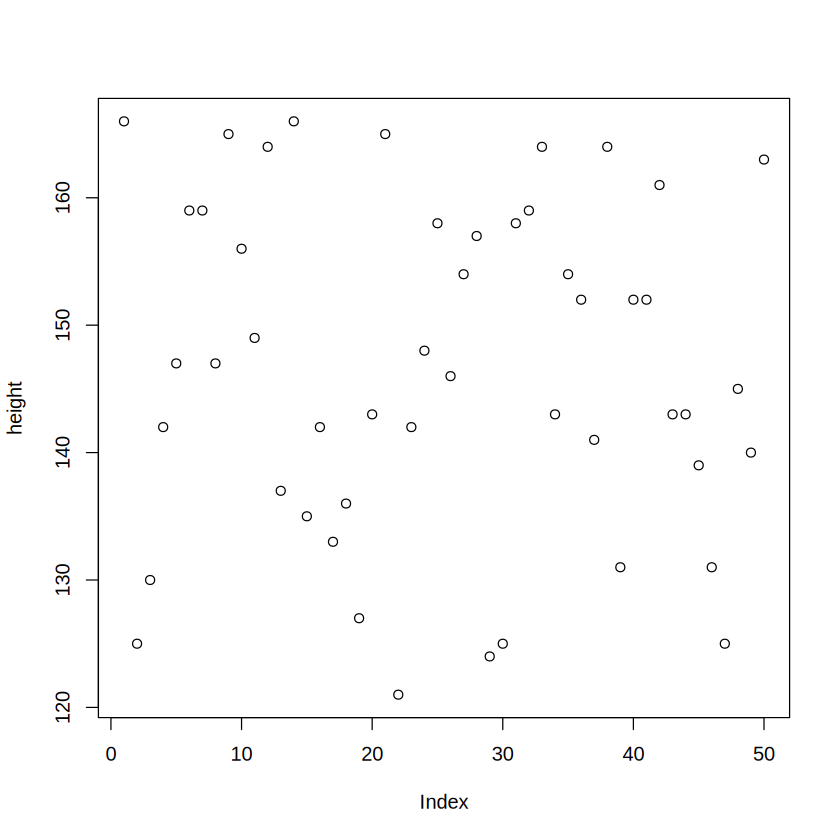

In [ ]:
height = c(
  166,125,130,142,147,159,159,147,165,156,149,164,137,166,135,142,
  133,136,127,143,165,121,142,148,158,146,154,157,124,125,158,159,
  164,143,154,152,141,164,131,152,152,161,143,143,139,131,125,145,
  140,163
)

plot(height)

### Scatter plot with a colour

The lecture changes the plotting colour by supplying the `col` argument.

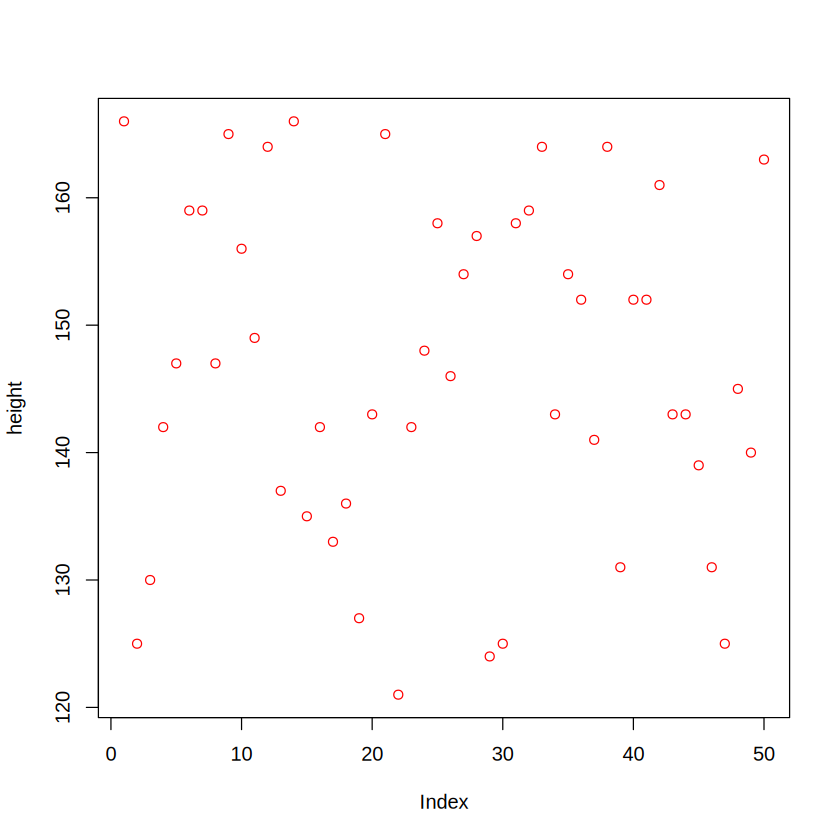

In [ ]:
plot(height, col = "red")

## 6. Bar plots

A bar plot visualizes absolute or relative frequencies of categorical values. The lecture demonstrates both forms using the `gender` data.

[1] 1 2 1 2 1 1 1 2 1 1

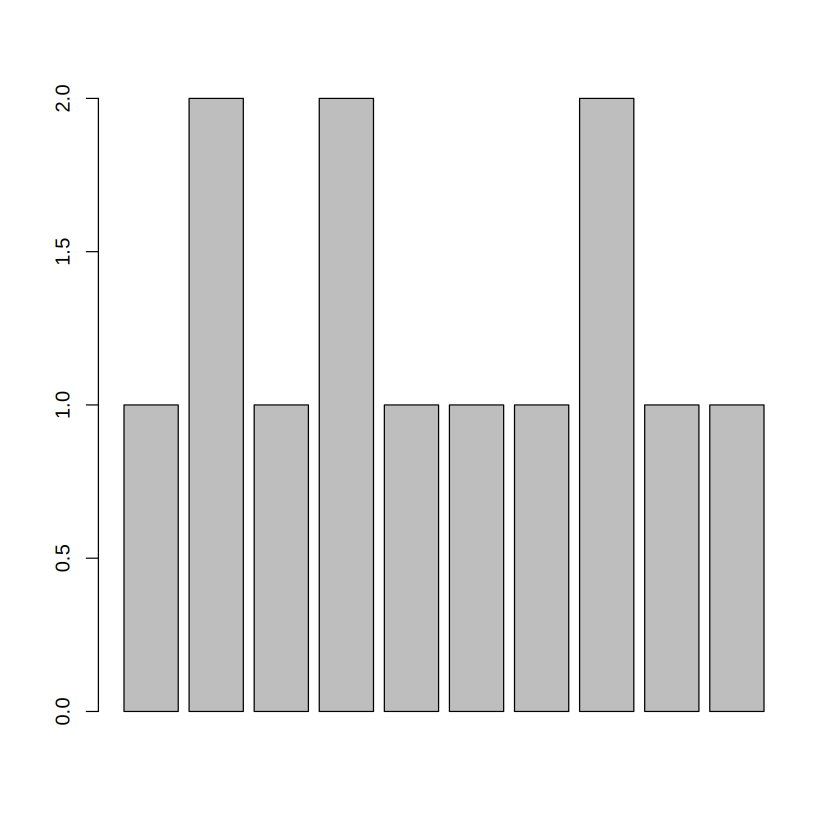

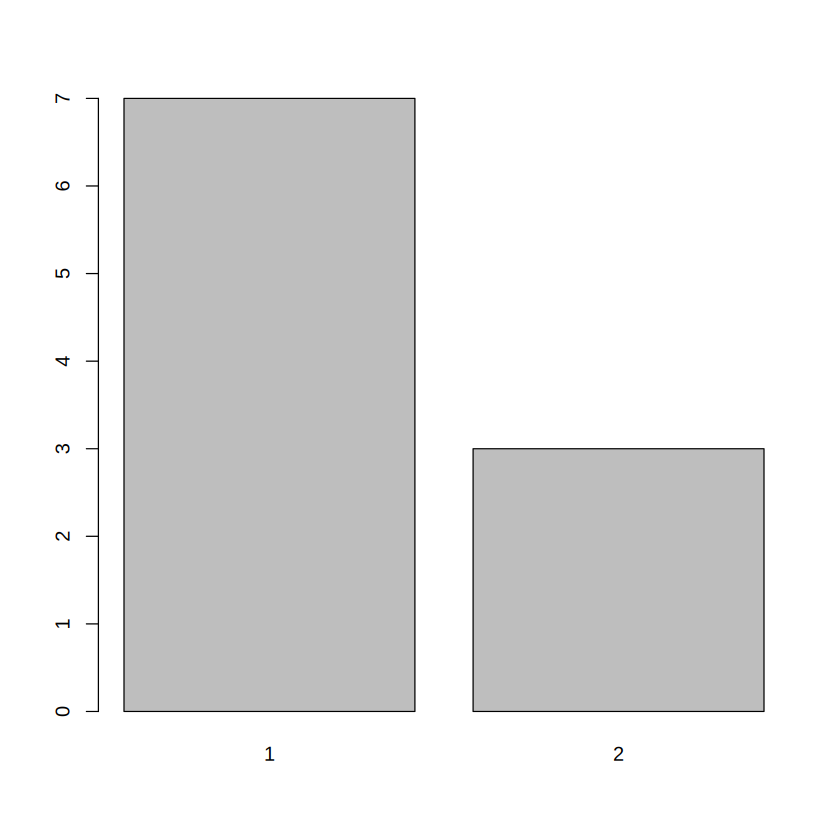

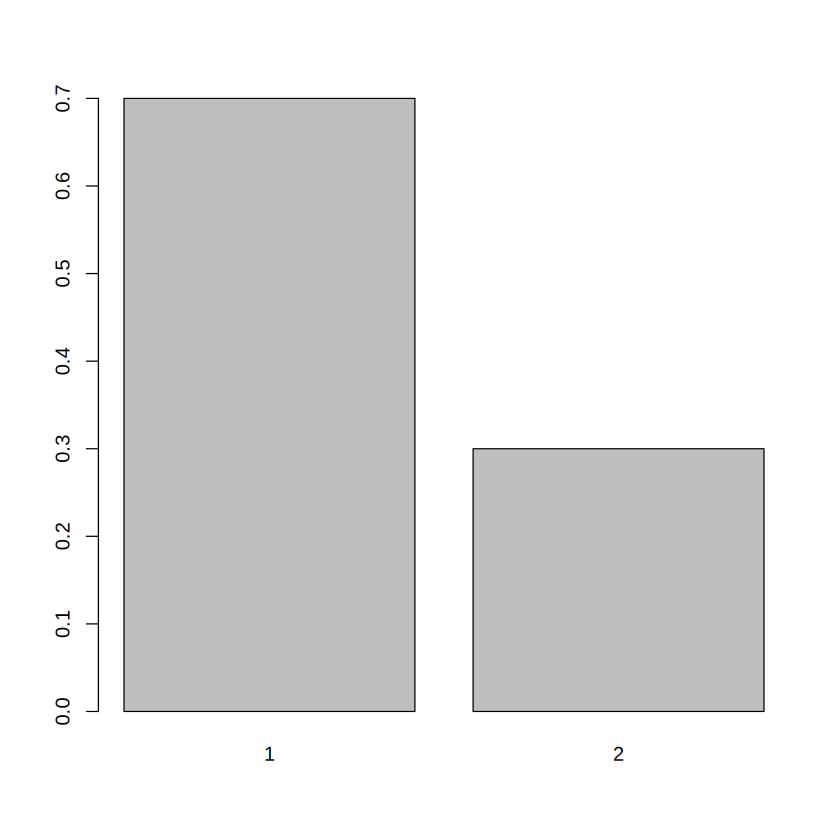

In [ ]:
gender = c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
gender

barplot(gender)
barplot(table(gender))
barplot(table(gender) / length(gender))

### Bar plots for delivery directions

The same absolute and relative-frequency bar plots are created for the three delivery directions.

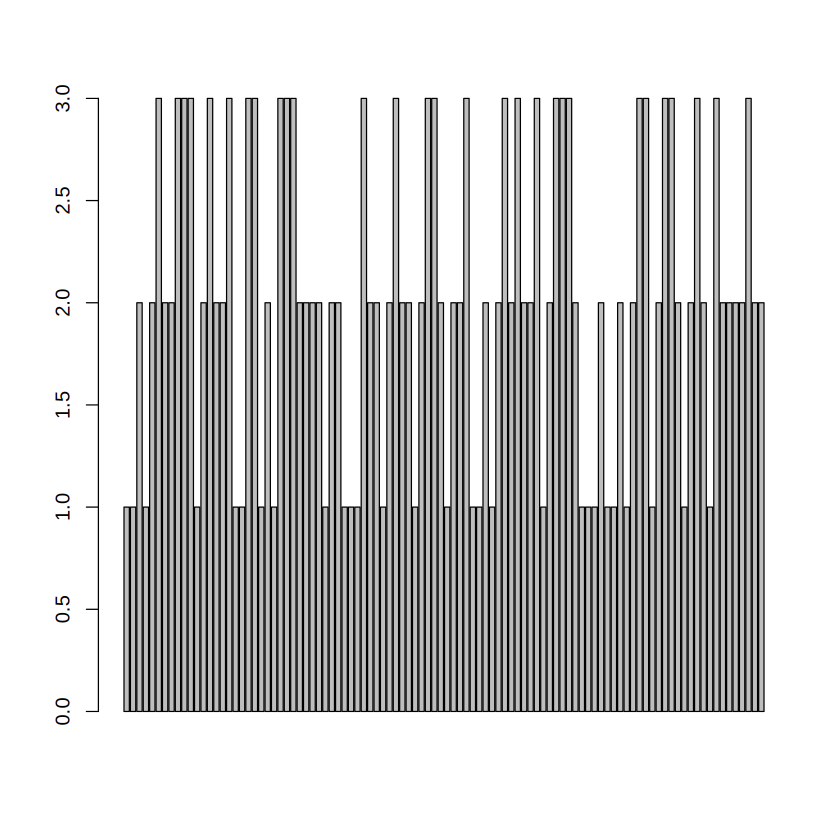

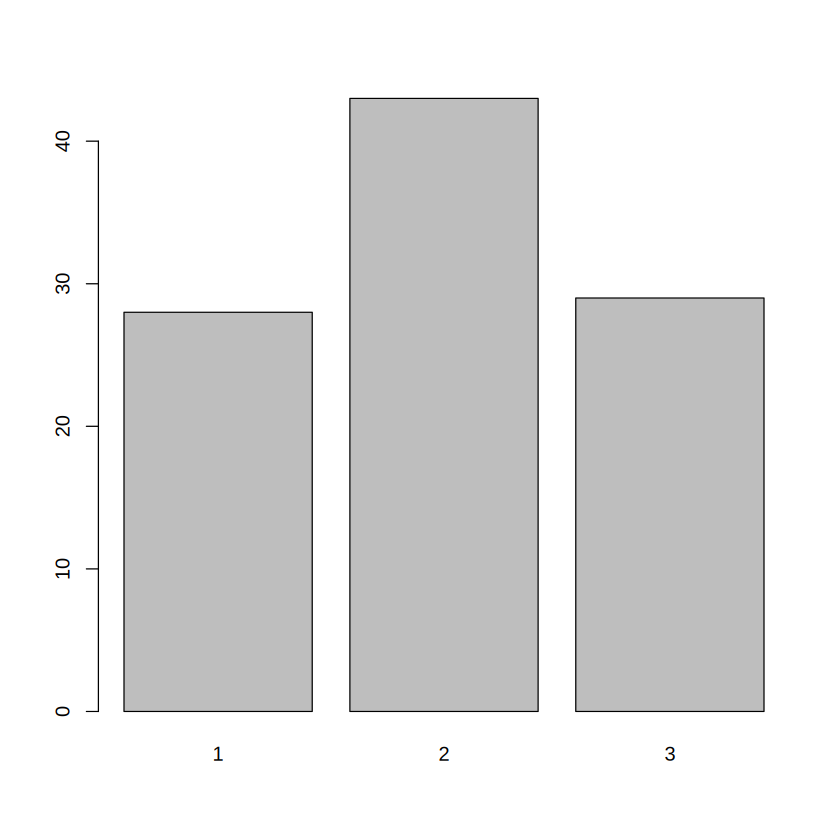

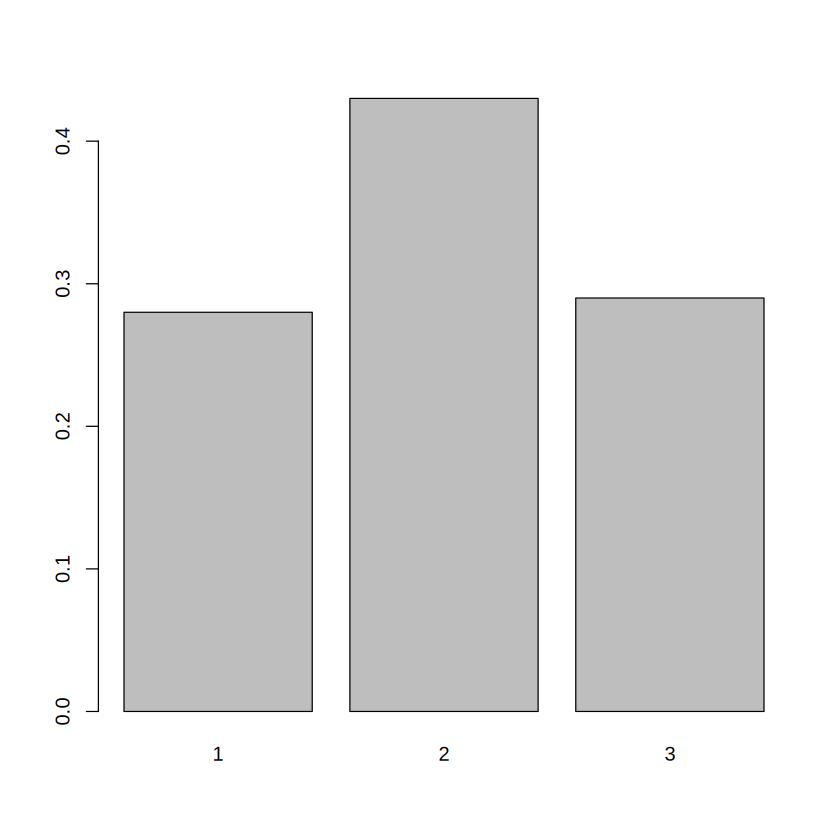

In [ ]:
barplot(direction)
barplot(table(direction))
barplot(table(direction) / length(direction))

### Adding colours

The lecture demonstrates how to assign different colours to the bars.

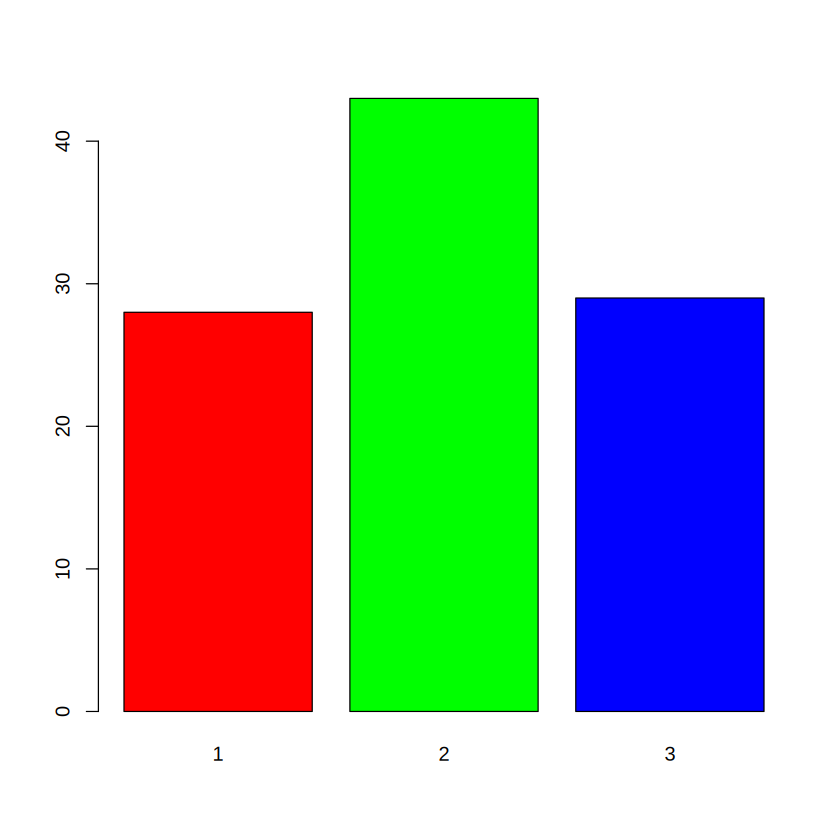

In [ ]:
barplot(table(direction), col = c("red", "green", "blue"))

### Adding a title

The `main` argument adds a title to the bar plot.

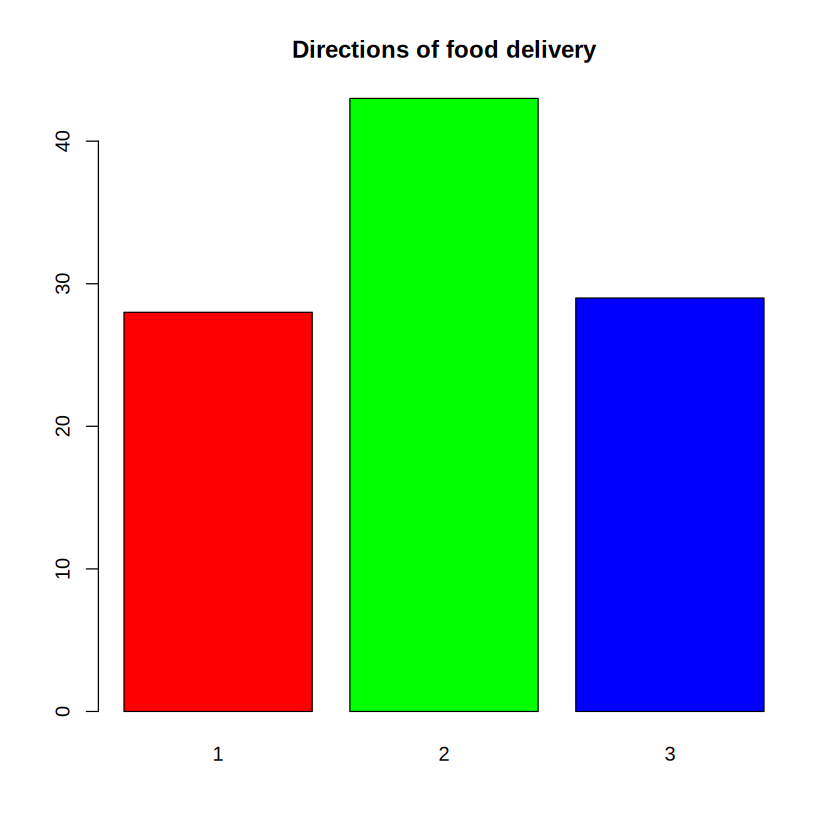

In [ ]:
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery"
)

### Adding a legend

The `legend.text` argument adds labels for the three direction categories.

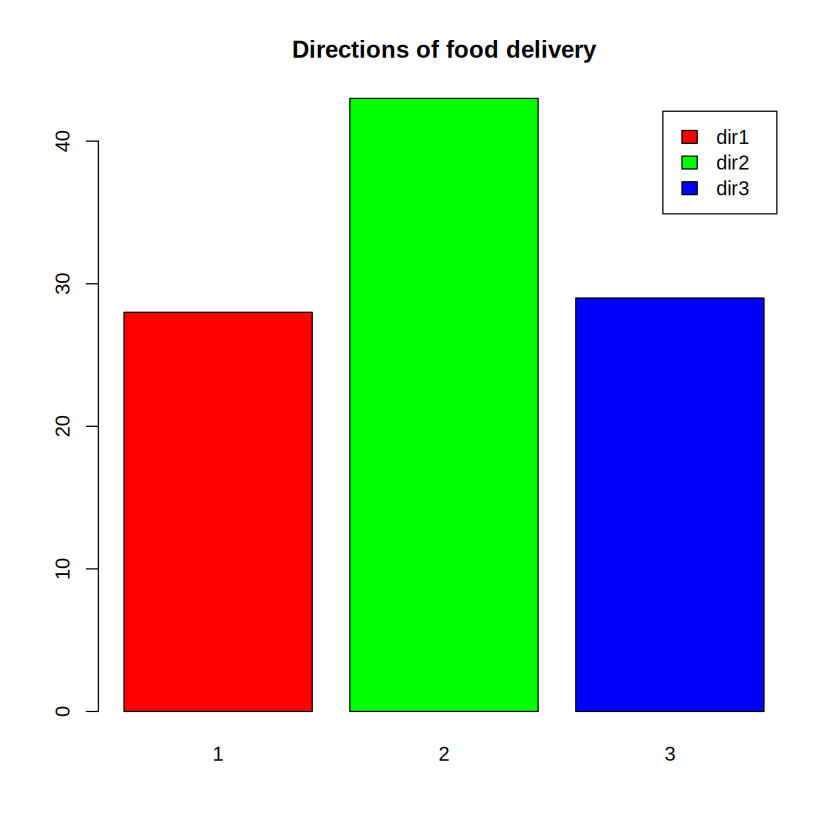

In [ ]:
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery",
  legend.text = c("dir1", "dir2", "dir3")
)

### Adding a subtitle

The `sub` argument adds a subtitle below the plot.

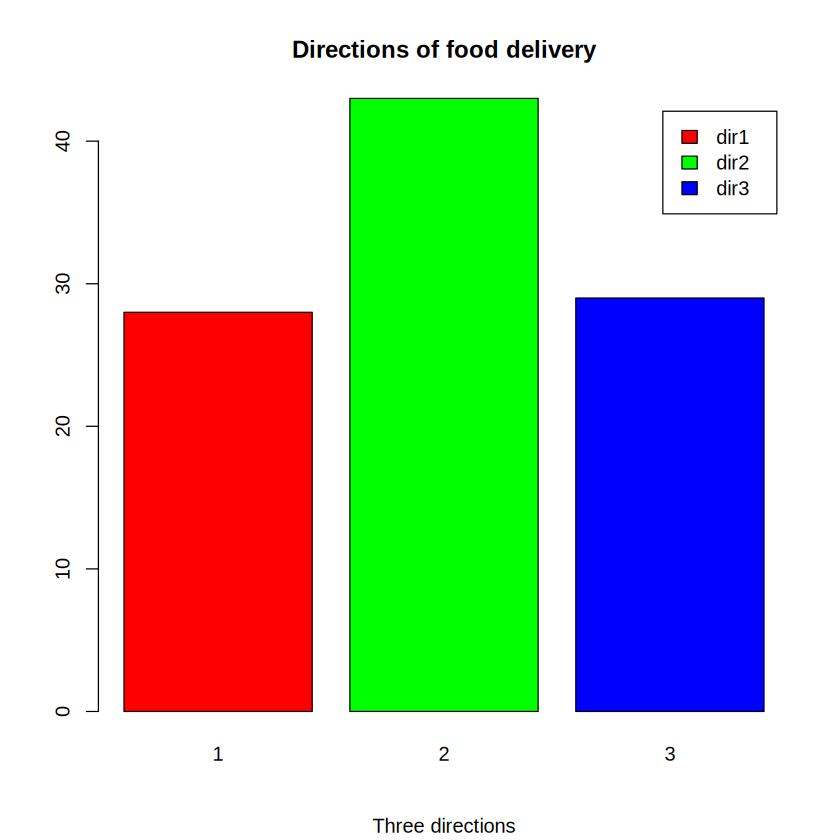

In [ ]:
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery",
  legend.text = c("dir1", "dir2", "dir3"),
  sub = "Three directions"
)

### Adding axis labels

The final example adds a subtitle, x-axis label and y-axis label.

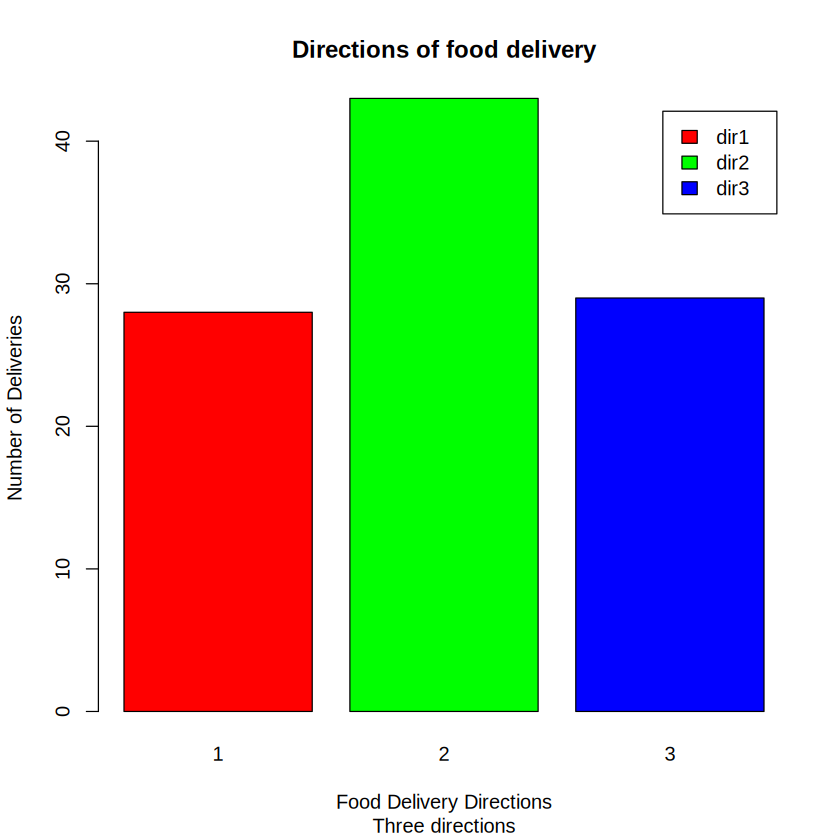

In [ ]:
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery",
  legend.text = c("dir1", "dir2", "dir3"),
  sub = "Three directions",
  xlab = "Food Delivery Directions",
  ylab = "Number of Deliveries"
)